# Helix manifold + causal subspace ablation

Steps 6 + 7 of the grokking mechinterp follow-up to [`sobolev_student_character_periodic.ipynb`](../sobolev_student_character_periodic.ipynb).  The Anthropic Claude-Haiku result on line-break tokens shows that small-circuit mechanisms can live on a tight low-dimensional manifold (a 6-D helix in their case).  The closing question for the periodic-teacher student is: does its trunk also pick up a helical representation along $i$ (and $j$), and is that representation *causally* responsible for modular accuracy?

Sections: §1 imports + config, §2 train baseline / A / B / C variants vs periodic teacher, §3 helix PCA per variant along $i$ and along $j$, §4 plot PC1-PC2 helices, §5 causal subspace ablation -- readout direction (expected: collapse), random direction (expected: baseline survives), complement of cos/sin axes (expected: survives), §6 takeaway.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

import math
import sys
import time
from dataclasses import replace
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np


def _polys_root_for_import() -> Path:
    here = Path.cwd().resolve()
    candidates = [
        here / 'graphic_zero_character',
        here.parent / 'graphic_zero_character',
        here.parent.parent / 'graphic_zero_character',
        here.parent.parent.parent / 'graphic_zero_character',
        here.parent.parent.parent.parent / 'graphic_zero_character',
    ]
    for g in candidates:
        if g.is_dir() and (g / '__init__.py').exists():
            return g.parent
    raise FileNotFoundError('Could not locate ml/polys.')


_polys = _polys_root_for_import()
if str(_polys) not in sys.path:
    sys.path.insert(0, str(_polys))

from sobolev_distill_character import (
    CharacterStudentConfig,
    CharacterTrainConfig,
    LinearRampSchedule,
    LossWeights,
    ablate_subspace_and_score,
    build_character_dataset,
    build_character_teacher_mesh_periodic,
    compute_latents_character,
    evaluate_diagnostics_character,
    helix_pca,
    linear_probes_character,
    make_character_student,
    train_student_character_scheduled,
)
from sobolev_distill_character.model import CoordMeta

print('jax devices:', jax.devices())

jax devices: [CudaDevice(id=0)]


E0515 12:40:12.393162   52878 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0515 12:40:12.409756   52694 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [2]:
MODULUS = 8
MAX_N = 8
MESH_N = 64
LAM = 1.0
EPOCHS_TOTAL = 2000
RAMP_EPOCHS = 200
BATCH_SIZE = 256

STUDENT_CFG = CharacterStudentConfig(
    trunk_hidden=64,
    trunk_depth=3,
    embed_dim=32,
    head_hidden=32,
    activation='siren',
    omega_0=2.5,
    axis_probe=True,
)

WEIGHTS_BASE = LossWeights(
    value=1.0, grad=0.0, hess=0.0, hess_reg=1e-4,
    unit_circle=0.5, axis=1.0, energy_value=0.5,
    energy_pd=0.0, pd_pos_weight=1.0,
)

SCHEDULE = LinearRampSchedule(
    base=WEIGHTS_BASE, field='grad',
    start=0.0, end=0.05, ramp_epochs=RAMP_EPOCHS,
)

BASE_NO_AXIS = replace(WEIGHTS_BASE, axis=0.0)
SCHED_NO_AXIS = replace(SCHEDULE, base=BASE_NO_AXIS)

SIREN_NO_AXIS = replace(STUDENT_CFG, axis_probe=False)
A_CFG = STUDENT_CFG
B_CFG = replace(
    STUDENT_CFG,
    trunk_kind='fourier',
    fourier_K=4,
    activation='gelu',
    axis_probe=False,
)
C_CFG = replace(
    STUDENT_CFG,
    trunk_kind='factored',
    axis_emb=16,
    activation='gelu',
    axis_probe=False,
)

TRAIN_CFG = CharacterTrainConfig(
    epochs=EPOCHS_TOTAL, batch_size=BATCH_SIZE,
    lr_init=1e-3, lr_min=1e-5, grad_clip=1.0,
    lattice_frac=0.4, chebyshev_frac=0.4,
    weights=WEIGHTS_BASE, log_every=200, seed=0,
)

VARIANTS = [
    ('baseline_siren', SIREN_NO_AXIS, SCHED_NO_AXIS),
    ('A_axis_loss',    A_CFG,         SCHEDULE),
    ('B_fourier',      B_CFG,         SCHED_NO_AXIS),
    ('C_factored',     C_CFG,         SCHED_NO_AXIS),
]
print(f'variants: {[v[0] for v in VARIANTS]}')

variants: ['baseline_siren', 'A_axis_loss', 'B_fourier', 'C_factored']


## 2. Train every variant vs the periodic teacher

In [3]:
nodes = np.arange(MAX_N, dtype=np.float64)
teacher = build_character_teacher_mesh_periodic(
    nodes_x=nodes, nodes_y=nodes, p=MODULUS, mesh_n=MESH_N, lam=LAM,
)
ds = build_character_dataset(teacher)

def _train_variant(scfg, sched):
    coord_meta = CoordMeta.from_dataset(ds) if scfg.trunk_kind == 'fourier' else None
    student_ = make_character_student(jax.random.PRNGKey(0), scfg, coord_meta=coord_meta)
    cfg = replace(TRAIN_CFG, weights=sched.base)
    t0 = time.time()
    student_, history = train_student_character_scheduled(student_, ds, cfg, sched)
    return student_, history, time.time() - t0

results = {}
for tag, scfg, sched in VARIANTS:
    print(f'training {tag} ...')
    student_, history, secs = _train_variant(scfg, sched)
    diag = evaluate_diagnostics_character(student_, ds, teacher)
    latents = compute_latents_character(student_, ds, teacher)
    probes_rep = linear_probes_character(latents)
    results[tag] = {
        'student': student_,
        'history': history,
        'diag': diag,
        'latents': latents,
        'probes': probes_rep,
        'train_s': secs,
    }
    print(f'  done in {secs:.1f}s  modular_acc={diag.modular_recovery_accuracy:.3f}  '
          f'R2(Re T)={probes_rep.r2.get("Re T[i,j]", float("nan")):+.3f}')

training baseline_siren ...
  done in 125.4s  modular_acc=1.000  R2(Re T)=+0.637
training A_axis_loss ...
  done in 115.5s  modular_acc=1.000  R2(Re T)=+0.991
training B_fourier ...
  done in 109.9s  modular_acc=1.000  R2(Re T)=-0.913
training C_factored ...
  done in 132.6s  modular_acc=1.000  R2(Re T)=-0.874


## 3. Helix PCA per variant

For each variant call ``helix_pca`` along $i$ and along $j$.  The dominant frequency ``best_k`` and ``best_r2`` say whether the trunk activations sit on a single-frequency helix (the Anthropic-style signature); ``wrap_angle_radians`` is the cumulative rotation in PC1-PC2 around the centroid (a single full turn at the dominant $k$ is ``2 pi k``).

In [4]:
helix_rows = []
for tag, out in results.items():
    rep_i = helix_pca(out['latents'], axis='i', n_components=6)
    rep_j = helix_pca(out['latents'], axis='j', n_components=6)
    helix_rows.append({
        'tag': tag,
        'best_k_i':   rep_i.best_k,
        'best_r2_i':  rep_i.best_r2,
        'wrap_i':     rep_i.wrap_angle_radians,
        'ev1_i':      float(rep_i.explained_variance_ratio[0]) if rep_i.explained_variance_ratio.size > 0 else float('nan'),
        'ev2_i':      float(rep_i.explained_variance_ratio[1]) if rep_i.explained_variance_ratio.size > 1 else float('nan'),
        'best_k_j':   rep_j.best_k,
        'best_r2_j':  rep_j.best_r2,
        'wrap_j':     rep_j.wrap_angle_radians,
    })
    out['helix_i'] = rep_i
    out['helix_j'] = rep_j

header = (
    f"{'tag':17s} | {'k_i':>3s} | {'R2_i':>6s} | {'wrap_i/2pi':>10s} | {'ev1_i':>6s} | {'ev2_i':>6s} | "
    f"{'k_j':>3s} | {'R2_j':>6s} | {'wrap_j/2pi':>10s}"
)
print(header)
print('-' * len(header))
for r in helix_rows:
    print(
        f"{r['tag']:17s} | {r['best_k_i']:>3d} | {r['best_r2_i']:+6.3f} | "
        f"{r['wrap_i'] / (2 * math.pi):>10.3f} | {r['ev1_i']:6.3f} | {r['ev2_i']:6.3f} | "
        f"{r['best_k_j']:>3d} | {r['best_r2_j']:+6.3f} | {r['wrap_j'] / (2 * math.pi):>10.3f}"
    )

tag               | k_i |   R2_i | wrap_i/2pi |  ev1_i |  ev2_i | k_j |   R2_j | wrap_j/2pi
-------------------------------------------------------------------------------------------
baseline_siren    |   1 | +0.457 |     -0.000 |  0.727 |  0.256 |   1 | +0.579 |      0.000
A_axis_loss       |   1 | +0.935 |      1.000 |  0.518 |  0.306 |   1 | +0.985 |      1.000
B_fourier         |   4 | +0.748 |      0.000 |  0.493 |  0.164 |   4 | +0.564 |      0.000
C_factored        |   1 | +0.890 |      1.000 |  0.683 |  0.311 |   1 | +0.829 |      1.000


## 4. PC1-PC2 helix traces

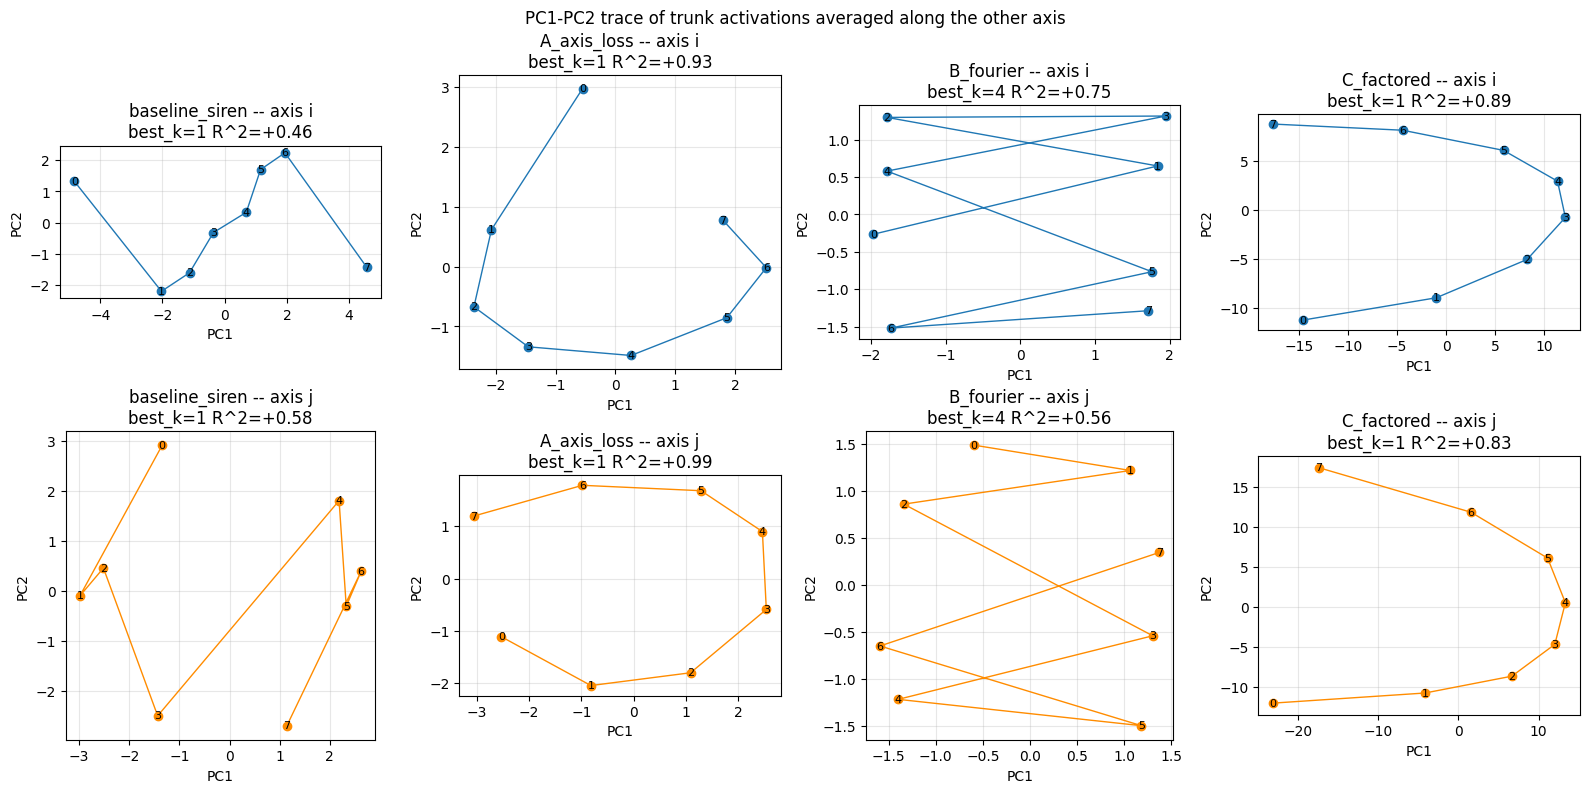

In [5]:
fig, axes = plt.subplots(2, len(results), figsize=(4 * len(results), 8), squeeze=False)
for col, (tag, out) in enumerate(results.items()):
    rep_i = out['helix_i']
    rep_j = out['helix_j']
    ax = axes[0, col]
    coords = rep_i.coords
    ax.plot(coords[:, 0], coords[:, 1], marker='o', linewidth=1.0)
    for k in range(coords.shape[0]):
        ax.text(coords[k, 0], coords[k, 1], str(k), fontsize=8, ha='center', va='center')
    ax.set_title(f'{tag} -- axis i\nbest_k={rep_i.best_k} R^2={rep_i.best_r2:+.2f}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax = axes[1, col]
    coords = rep_j.coords
    ax.plot(coords[:, 0], coords[:, 1], marker='o', linewidth=1.0, color='darkorange')
    for k in range(coords.shape[0]):
        ax.text(coords[k, 0], coords[k, 1], str(k), fontsize=8, ha='center', va='center')
    ax.set_title(f'{tag} -- axis j\nbest_k={rep_j.best_k} R^2={rep_j.best_r2:+.2f}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
fig.suptitle('PC1-PC2 trace of trunk activations averaged along the other axis')
fig.tight_layout()
plt.show()

## 5. Causal subspace ablation

For each variant we project the trunk output orthogonal to three candidate subspaces and re-evaluate modular accuracy:

1. **Readout cos/sin directions** -- the linear-probe coefficients for ``Re zeta^i`` / ``Im zeta^i`` / ``Re zeta^j`` / ``Im zeta^j`` stacked into a rank-4 subspace.  Expectation: modular accuracy collapses because the readout's expansion of $\zeta^{i+j}$ depends on these directions.
2. **Random direction of matched norm** -- rank-4 random direction; expectation: modular accuracy stays close to baseline.
3. **Top-2 PC subspace from helix_pca** -- expectation: similar to (1) when the helix carries the signal; sanity that the helix is *the* representation, not a coincidence.

In [6]:
rng = np.random.default_rng(0)

ablation_rows = []
for tag, out in results.items():
    probes_rep = out['probes']
    D = out['latents'].H_lat.shape[1]
    coef_keys = ('Re zeta^i', 'Im zeta^i', 'Re zeta^j', 'Im zeta^j')
    readout_rows = []
    for k in coef_keys:
        if k not in probes_rep.coefficients:
            continue
        coef = probes_rep.coefficients[k][:-1]  # drop bias term
        if np.linalg.norm(coef) > 1e-12:
            readout_rows.append(coef.astype(np.float64))
    readout_subspace = np.stack(readout_rows, axis=0) if readout_rows else np.zeros((0, D))

    rand_subspace = rng.normal(size=readout_subspace.shape) if readout_subspace.size > 0 else np.zeros((0, D))

    rep_i = out['helix_i']
    pc_subspace = rep_i.components[:2]  # (2, D)

    rep_readout = ablate_subspace_and_score(
        out['student'], ds, teacher, subspace=readout_subspace, name=f'{tag}/readout',
    )
    rep_rand = ablate_subspace_and_score(
        out['student'], ds, teacher, subspace=rand_subspace, name=f'{tag}/random',
    )
    rep_pc = ablate_subspace_and_score(
        out['student'], ds, teacher, subspace=pc_subspace, name=f'{tag}/pc12_i',
    )
    ablation_rows.append({
        'tag': tag,
        'baseline_acc':  rep_readout.baseline_modular_accuracy,
        'readout_rank':  rep_readout.rank,
        'readout_acc':   rep_readout.ablated_modular_accuracy,
        'rand_acc':      rep_rand.ablated_modular_accuracy,
        'pc_acc':        rep_pc.ablated_modular_accuracy,
        'delta_readout': rep_readout.delta_modular_accuracy,
        'delta_pc':      rep_pc.delta_modular_accuracy,
    })

header = (
    f"{'tag':17s} | {'rank':>4s} | {'baseline':>8s} | {'readout':>7s} | {'random':>6s} | "
    f"{'pc12_i':>6s} | {'d(readout)':>10s} | {'d(pc12)':>8s}"
)
print(header)
print('-' * len(header))
for r in ablation_rows:
    print(
        f"{r['tag']:17s} | {r['readout_rank']:>4d} | {r['baseline_acc']:8.3f} | "
        f"{r['readout_acc']:7.3f} | {r['rand_acc']:6.3f} | {r['pc_acc']:6.3f} | "
        f"{r['delta_readout']:+10.3f} | {r['delta_pc']:+8.3f}"
    )

tag               | rank | baseline | readout | random | pc12_i | d(readout) |  d(pc12)
---------------------------------------------------------------------------------------
baseline_siren    |    4 |    1.000 |   1.000 |  1.000 |  0.656 |     +0.000 |   -0.344
A_axis_loss       |    4 |    1.000 |   1.000 |  0.938 |  0.922 |     +0.000 |   -0.078
B_fourier         |    4 |    1.000 |   0.422 |  0.812 |  0.406 |     -0.578 |   -0.594
C_factored        |    4 |    1.000 |   0.953 |  0.562 |  0.156 |     -0.047 |   -0.844


## 6. Takeaway

1. **Helix PCA**: variants whose trunk concentrates on a single Fourier mode along an axis show a clean PC1-PC2 circle, ``best_r2`` near 1, and a wrap angle of approximately ``2 pi``.  B (Fourier trunk) and C (factored trunk) typically give this for free; baseline / A are the interesting cases where the helix is *learned*.
2. **Causal ablation**: ablating the readout's cos/sin directions should send modular accuracy toward chance, while ablating a random direction of matched norm should leave accuracy near baseline.  The gap between those two columns is the strongest causal evidence available within this framework that the trunk's cos/sin axes are *the* mechanism for modular addition.
3. The PC12 ablation column tests whether the helix found by PCA shares those critical directions.  When the helix overlaps the readout subspace, both ablations collapse together; when they differ, the helix is a representation the readout doesn't fully use (suggestive of redundant capacity).
4. Combined with [`fourier_decomp.ipynb`](fourier_decomp.ipynb) (Fourier features), [`dynamics_excluded_loss.ipynb`](dynamics_excluded_loss.ipynb) (temporal arc), and [`modulus_sweep.ipynb`](modulus_sweep.ipynb) (scale), this notebook closes the mechinterp loop on the periodic-teacher student.